# Environmental Classification

## Imports

In [30]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().resolve()))
from shared.model_defs import GreenMonthTransformer
from shared.train_utils import run_epoch


## Data: CO₂ correlation and loaders

State-level annual CO₂ uses MSN **TETCE** from `complete_seds_all_energy_1960_2023.csv` (million metric tons). Monthly generation mix is from `electric_power_operations_monthly_all_states.csv`. **Green month** = renewable share ≥ state median (or global median if a state has very few months); model inputs do **not** include `ren_share`.

In [44]:
from green_dirty_month_data import build_labeled_frame, make_loaders

# Cross-section (states): mean monthly fossil / renewable share vs annual TETCE (2023)
frame = build_labeled_frame(co2_year=2023)
by_state = frame.groupby("location", as_index=False).agg(
    mean_fos_share=("fos_share", "mean"),
    mean_ren_share=("ren_share", "mean"),
    tetce_mmt=("tetce_mmt", "first"),
)
r_fos = by_state["tetce_mmt"].corr(other=by_state["mean_fos_share"], method="pearson")
r_ren = by_state["tetce_mmt"].corr(other=by_state["mean_ren_share"], method="pearson")
print("Pearson r (states): TETCE vs mean fossil share  =", round(r_fos, 4))
print("Pearson r (states): TETCE vs mean renewable share =", round(r_ren, 4))

train_loader, test_loader, info = make_loaders(batch_size=32, test_size=0.3, random_state=42)
print(
    "n_states", info["n_states"],
    "| train batches", len(train_loader),
    "| test batches", len(test_loader),
)
print("Approx. class balance (full sample):", info["class_balance"])

Pearson r (states): TETCE vs mean fossil share  = 0.1521
Pearson r (states): TETCE vs mean renewable share = -0.1598
n_states 49 | train batches 13 | test batches 6


KeyError: 'class_balance'

## Greenest states by month

**Greenest** = highest **renewable share** (`REN / ALL` generation) among states in the monthly EIA extract. For each month, states are ranked and the top few are shown (not the ML label).

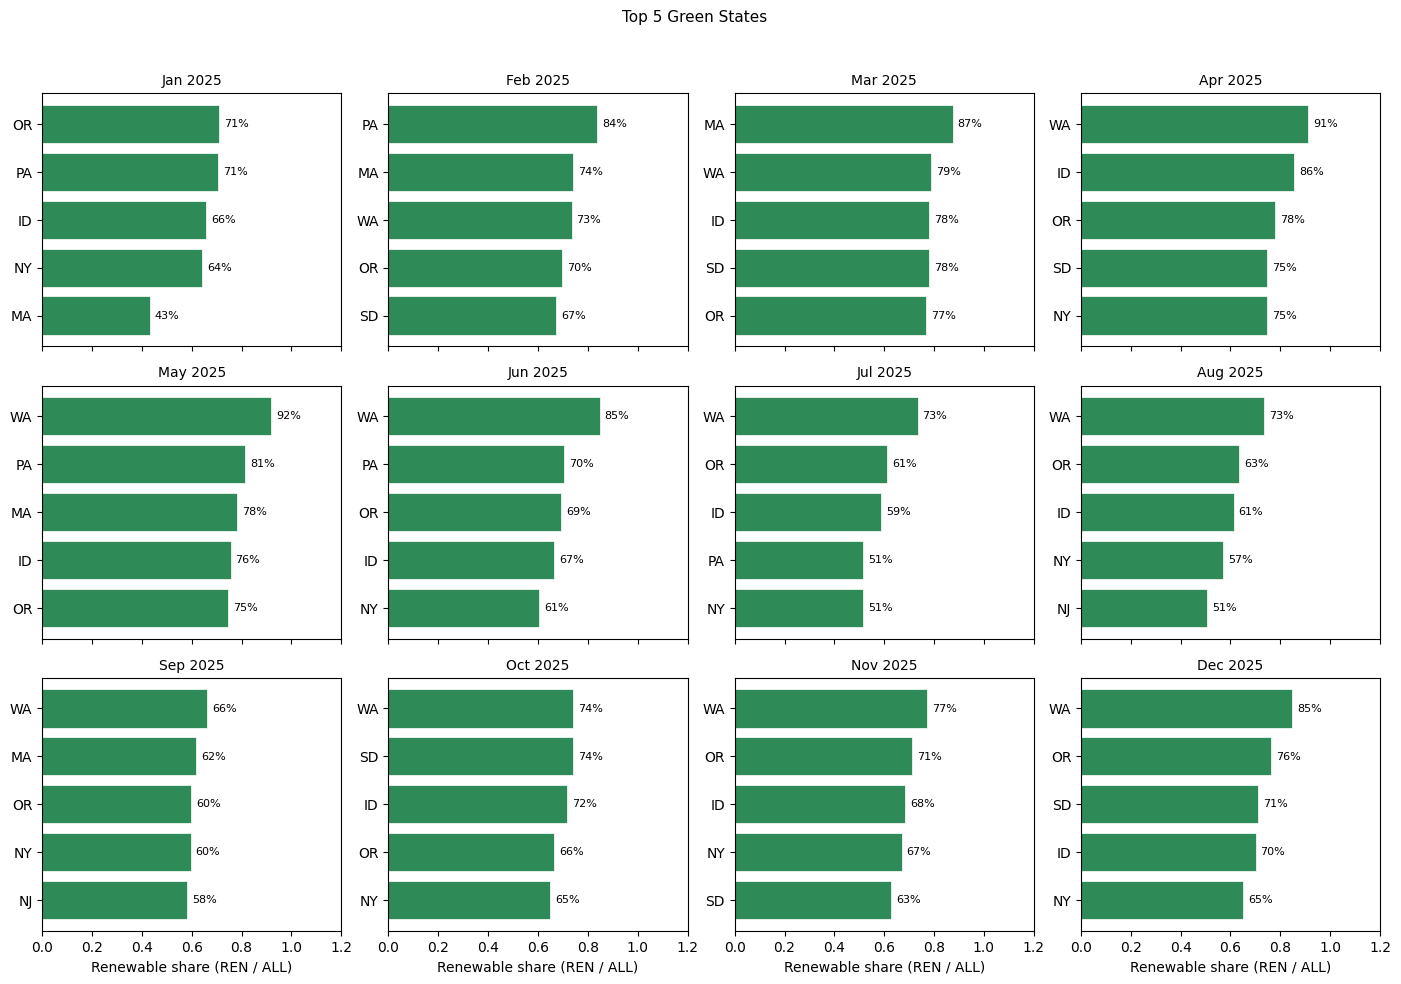

In [45]:
import importlib

import green_dirty_month_data as _gdm

# Reload so Jupyter picks up edits to ``green_dirty_month_data.py`` (kernel caches imports).
importlib.reload(_gdm)
from green_dirty_month_data import monthly_top_green_states

TOP_N = 5
# Exclude from the top-by-ren_share slice (next-highest states fill in).
EXCLUDE_STATES = ("VT", "MT", "IA")
ranked = monthly_top_green_states(
    top_n=TOP_N, also_include=(), exclude_states=EXCLUDE_STATES
)
months_sorted = sorted(ranked["period"].unique())
n_m = len(months_sorted)
ncols = 4
nrows = int(np.ceil(n_m / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for i, m in enumerate(months_sorted):
    ax = axes[i]
    sub = ranked[ranked["period"] == m].sort_values("rank")
    ax.barh(sub["state"], sub["ren_share"], color="seagreen", edgecolor="white", linewidth=0.5)
    ax.set_xlim(0, 1.2)
    ax.invert_yaxis()
    ax.set_title(pd.Timestamp(m).strftime("%b %Y"), fontsize=10)
    if i >= n_m - ncols:
        ax.set_xlabel("Renewable share (REN / ALL)")
    for _, r in sub.iterrows():
        ax.text(
            r["ren_share"] + 0.02,
            r["state"],
            f"{r['ren_share']:.0%}",
            va="center",
            fontsize=8,
        )
for j in range(len(months_sorted), len(axes)):
    axes[j].set_visible(False)
plt.suptitle(
    "Top 5 Green States",
    y=1.02,
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Transformer classifier

State embedding is concatenated to each token; encoder uses masked mean pooling over non-padded timesteps.

In [20]:
# Model imported from shared.model_defs in the imports cell.


## Training, metrics, and baselines

Test split is **30%**, stratified, `random_state=42`. Baselines: majority class and logistic regression on the **last timestep** features (same split as the transformer).

**Note:** $R^2$ and **MAE** below use the **predicted probability of class “green”** vs. binary labels (0/1)—they summarize probability calibration, not a regression target. The next section plots metrics over epochs and test-set predictions.

In [23]:
from green_dirty_month_data import tabular_last_timestep

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GreenMonthTransformer(
    n_features=info["n_features"],
    n_states=info["n_states"],
).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Use shared training helper to avoid notebook drift.
def run_epoch_local(loader, train: bool):
    optimizer = opt if train else None
    return run_epoch(model, loader, loss_fn, optimizer, device)


epoch   1  loss=0.7152  train_acc=0.527  test_acc=0.554  test_R2=0.013  test_MAE=0.490
epoch  20  loss=0.4639  train_acc=0.767  test_acc=0.702  test_R2=0.136  test_MAE=0.356
epoch  40  loss=0.2947  train_acc=0.854  test_acc=0.732  test_R2=0.143  test_MAE=0.288
epoch  60  loss=0.2841  train_acc=0.870  test_acc=0.702  test_R2=-0.078  test_MAE=0.318
epoch  80  loss=0.1435  train_acc=0.939  test_acc=0.726  test_R2=0.033  test_MAE=0.274
epoch 100  loss=0.1453  train_acc=0.941  test_acc=0.720  test_R2=-0.027  test_MAE=0.296
epoch 120  loss=0.2940  train_acc=0.918  test_acc=0.708  test_R2=-0.051  test_MAE=0.295
epoch 140  loss=0.0703  train_acc=0.974  test_acc=0.726  test_R2=-0.039  test_MAE=0.285
epoch 160  loss=0.1194  train_acc=0.944  test_acc=0.714  test_R2=-0.023  test_MAE=0.286
epoch 180  loss=0.0109  train_acc=0.997  test_acc=0.714  test_R2=-0.023  test_MAE=0.272
epoch 200  loss=0.0587  train_acc=0.982  test_acc=0.720  test_R2=-0.048  test_MAE=0.280
epoch 220  loss=0.0466  train_acc=0.

## Plots: metrics over training, confusion matrices, predictions

Training curves use the **test** set each epoch (for monitoring). **R²** and **MAE** compare binary true labels to predicted **P(green)**. Confusion matrices use hard class predictions. The scatter plot shows **P(green)** vs. test sample index, colored by true class, with incorrect predictions circled.

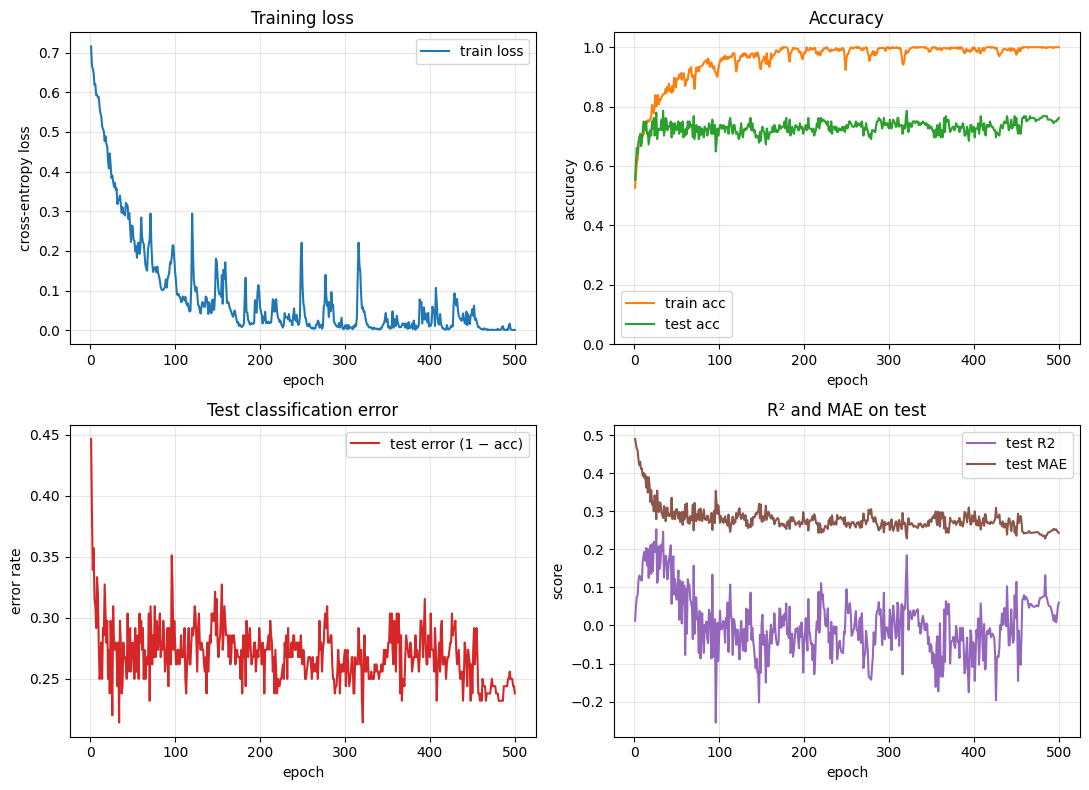

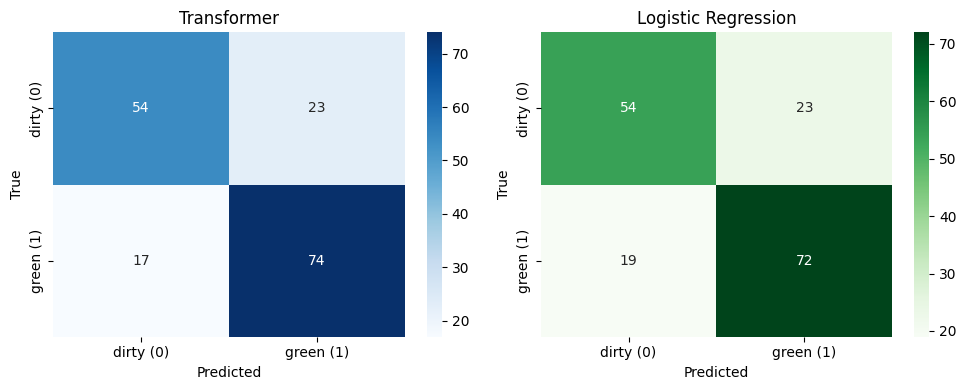

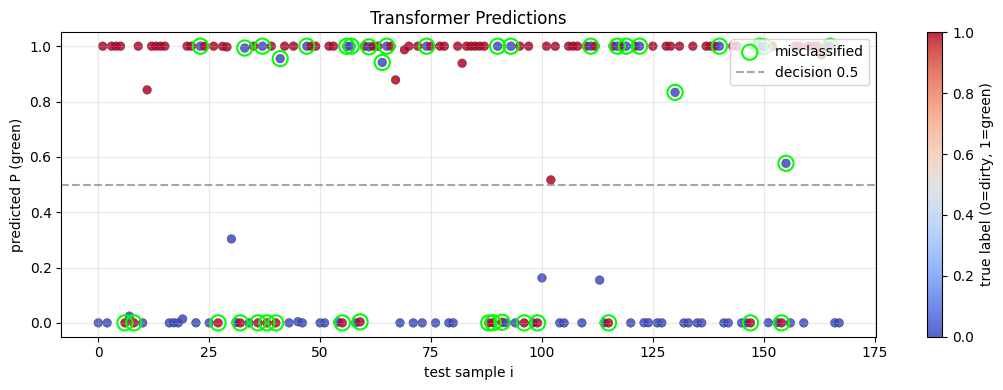

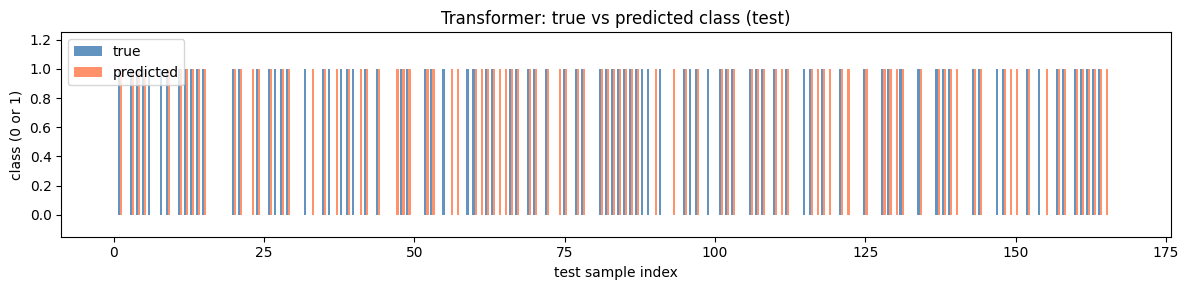

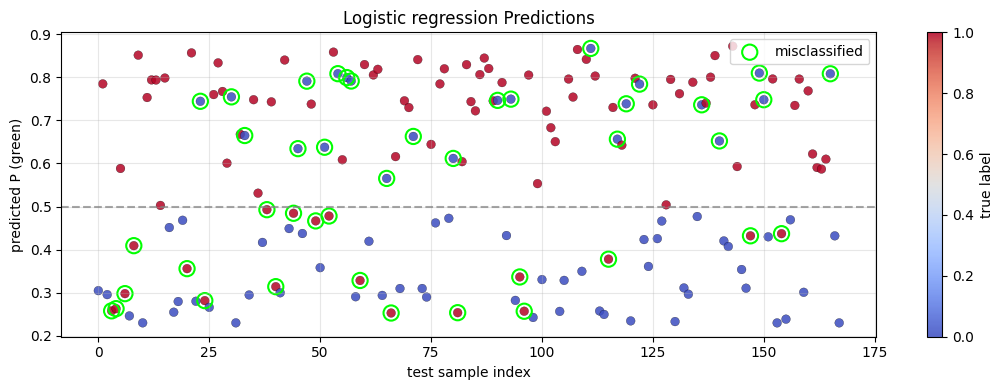

In [28]:
epochs = np.arange(1, n_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
ax = axes[0, 0]
ax.plot(epochs, history["train_loss"], color="C0", label="train loss")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy loss")
ax.set_title("Training loss")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 1]
ax.plot(epochs, history["train_acc"], label="train acc", color="C1")
ax.plot(epochs, history["test_acc"], label="test acc", color="C2")
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 0]
ax.plot(epochs, history["test_err"], color="C3", label="test error (1 − acc)")
ax.set_xlabel("epoch")
ax.set_ylabel("error rate")
ax.set_title("Test classification error")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 1]
ax.plot(epochs, history["test_r2"], label="test R2", color="C4")
ax.plot(epochs, history["test_mae"], label="test MAE", color="C5")
ax.set_xlabel("epoch")
ax.set_ylabel("score")
ax.set_title("R² and MAE on test")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# --- Confusion matrices (transformer vs logistic regression) ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels_disp = ["dirty (0)", "green (1)"]
cm_tf = confusion_matrix(y_te, p_te)
cm_lr = confusion_matrix(y_test, lr_p)
sns.heatmap(
    cm_tf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_disp,
    yticklabels=labels_disp,
    ax=axes[0],
)
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")
axes[0].set_title("Transformer")

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels_disp,
    yticklabels=labels_disp,
    ax=axes[1],
)
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")
axes[1].set_title("Logistic Regression")
plt.tight_layout()
plt.show()

# --- Predicted P(green): transformer vs test index ---
idx = np.arange(len(y_te))
wrong = p_te != y_te
fig, ax = plt.subplots(figsize=(11, 4))
sc = ax.scatter(
    idx,
    prob_te,
    c=y_te,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=40,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)
ax.scatter(
    idx[wrong],
    prob_te[wrong],
    s=120,
    facecolors="none",
    edgecolors="lime",
    linewidths=1.5,
    label="misclassified",
)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("true label (0=dirty, 1=green)")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="decision 0.5")
ax.set_xlabel("test sample i")
ax.set_ylabel("predicted P (green)")
ax.set_title("Transformer Predictions")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Side-by-side: true labels vs hard predictions ---
fig, ax = plt.subplots(figsize=(12, 3))
x = np.arange(len(y_te))
w = 0.35
ax.bar(x - w / 2, y_te, width=w, label="true", alpha=0.85, color="steelblue")
ax.bar(x + w / 2, p_te, width=w, label="predicted", alpha=0.85, color="coral")
ax.set_xlabel("test sample index")
ax.set_ylabel("class (0 or 1)")
ax.set_title("Transformer: true vs predicted class (test)")
ax.legend()
ax.set_ylim(-0.15, 1.25)
plt.tight_layout()
plt.show()

# --- Logistic regression: P(green) vs index ---
wrong_lr = lr_p != y_test
fig, ax = plt.subplots(figsize=(11, 4))
sc2 = ax.scatter(
    np.arange(len(y_test)),
    lr_prob,
    c=y_test,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=40,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)
ax.scatter(
    np.arange(len(y_test))[wrong_lr],
    lr_prob[wrong_lr],
    s=120,
    facecolors="none",
    edgecolors="lime",
    linewidths=1.5,
    label="misclassified",
)
plt.colorbar(sc2, ax=ax).set_label("true label")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("test sample index")
ax.set_ylabel("predicted P (green)")
ax.set_title("Logistic regression Predictions")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

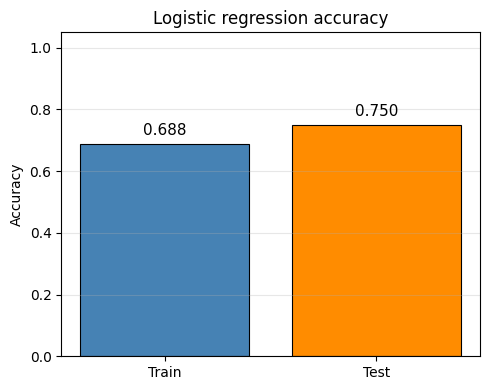

In [29]:
fig, ax = plt.subplots(figsize=(5, 4))
cats = ["Train", "Test"]
accs = [lr_train_acc, lr_test_acc]
colors = ["steelblue", "darkorange"]
bars = ax.bar(cats, accs, color=colors, edgecolor="k", linewidth=0.8)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Logistic regression accuracy")
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=11)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()